In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

df = X.copy()
df["target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
print(df.shape)
df.info()
df.describe()

(569, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [4]:
df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

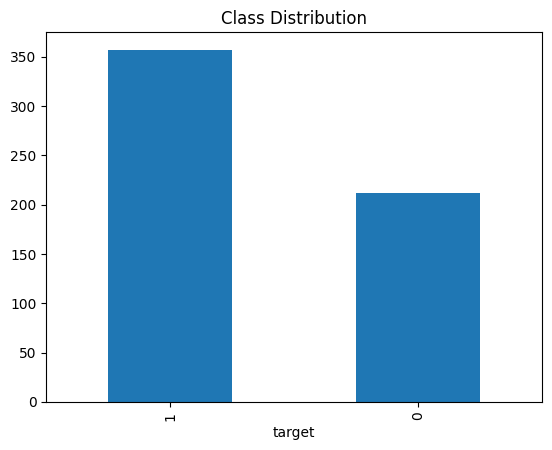

In [3]:
import matplotlib.pyplot as plt

df["target"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.show()

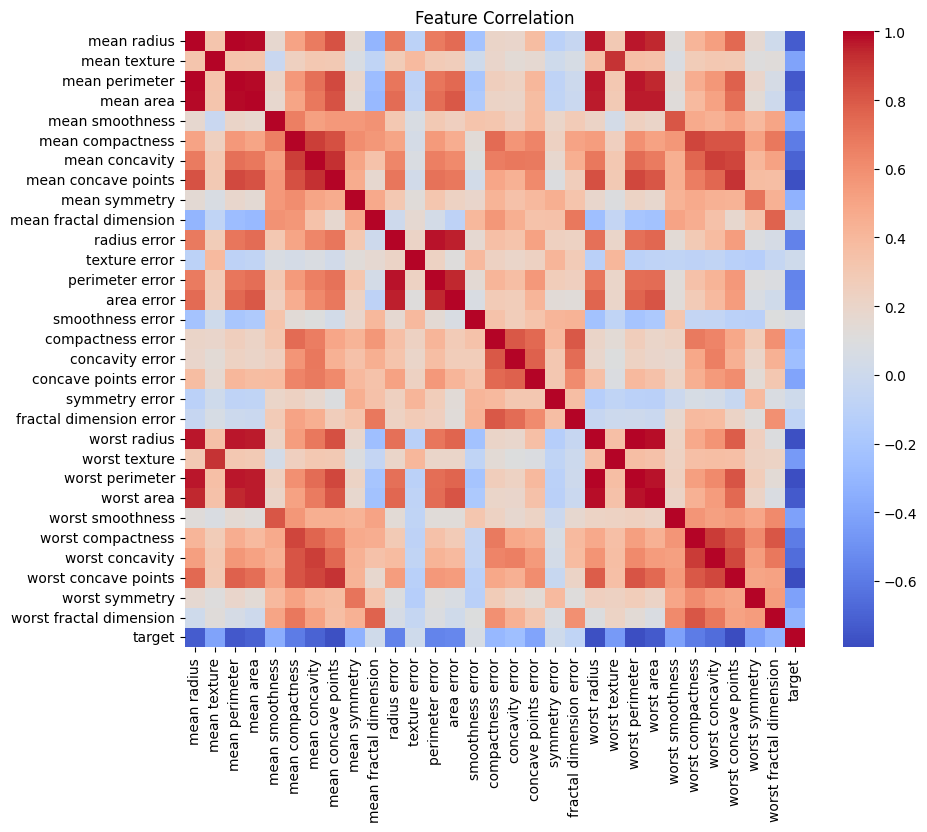

In [4]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(455, 30) (114, 30)


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=10000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9824561403508771
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [42]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.9473684210526315
              precision    recall  f1-score   support

           0       0.95      0.90      0.93        42
           1       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



/Users/nikitapatil/miniconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:13:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [43]:
from sklearn.metrics import roc_auc_score, roc_curve

xgb_probs = xgb.predict_proba(X_test)[:, 1]

xgb_auc = roc_auc_score(y_test, xgb_probs)

print("XGBoost AUC:", xgb_auc)

XGBoost AUC: 0.9943783068783069


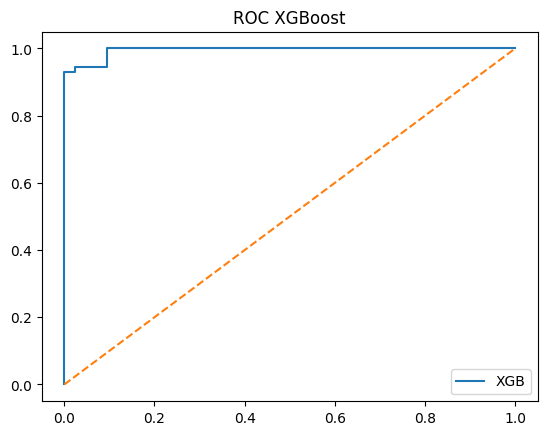

In [44]:
fpr, tpr, _ = roc_curve(y_test, xgb_probs)

plt.plot(fpr, tpr, label="XGB")
plt.plot([0,1],[0,1],"--")
plt.legend()
plt.title("ROC XGBoost")
plt.show()

In [12]:
log_acc = accuracy_score(y_test, y_pred)
rf_acc = accuracy_score(y_test, rf_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)

print("Logistic:", log_acc)
print("RandomForest:", rf_acc)
print("XGBoost:", xgb_acc)

Logistic: 0.9824561403508771
RandomForest: 0.956140350877193
XGBoost: 0.9473684210526315


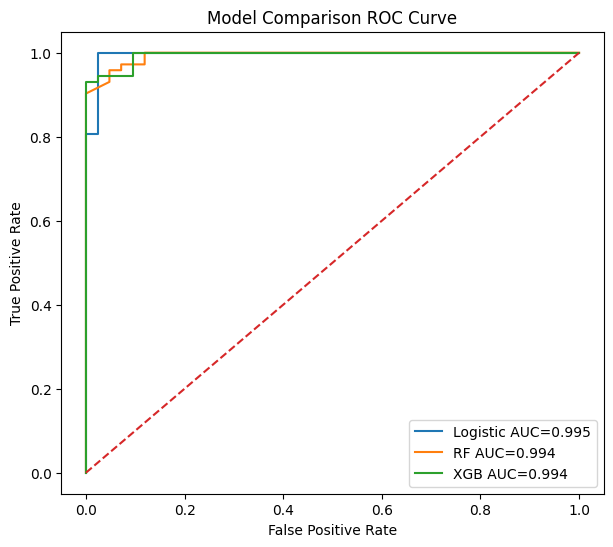

In [13]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# probabilities
log_probs = model.predict_proba(X_test_scaled)[:, 1]
rf_probs = rf.predict_proba(X_test)[:, 1]
xgb_probs = xgb.predict_proba(X_test)[:, 1]

# AUC
log_auc = roc_auc_score(y_test, log_probs)
rf_auc = roc_auc_score(y_test, rf_probs)
xgb_auc = roc_auc_score(y_test, xgb_probs)

# ROC curves
log_fpr, log_tpr, _ = roc_curve(y_test, log_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(7,6))

plt.plot(log_fpr, log_tpr, label=f"Logistic AUC={log_auc:.3f}")
plt.plot(rf_fpr, rf_tpr, label=f"RF AUC={rf_auc:.3f}")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGB AUC={xgb_auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model Comparison ROC Curve")
plt.legend()
plt.show()

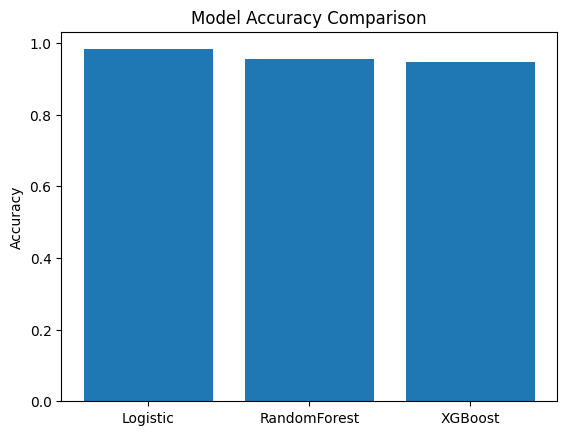

In [14]:
import matplotlib.pyplot as plt

names = ["Logistic", "RandomForest", "XGBoost"]
scores = [log_acc, rf_acc, xgb_acc]

plt.bar(names, scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [15]:
import numpy as np

unique, counts = np.unique(y_train, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

Class 0: 170
Class 1: 285


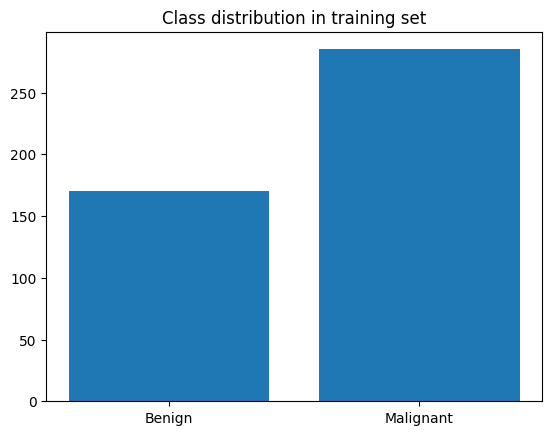

In [16]:
import matplotlib.pyplot as plt

plt.bar(["Benign", "Malignant"], counts)
plt.title("Class distribution in training set")
plt.show()

In [17]:
from sklearn.linear_model import LogisticRegression

model_bal = LogisticRegression(
    max_iter=10000,
    class_weight="balanced"
)

model_bal.fit(X_train_scaled, y_train)

y_pred_bal = model_bal.predict(X_test_scaled)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_bal))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_bal = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

rf_bal.fit(X_train, y_train)

rf_bal_pred = rf_bal.predict(X_test)

print(classification_report(y_test, rf_bal_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        42
           1       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [19]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before:", X_train.shape)
print("After:", X_train_sm.shape)

Before: (455, 30)
After: (570, 30)


In [20]:
rf_sm = RandomForestClassifier(random_state=42)

rf_sm.fit(X_train_sm, y_train_sm)

rf_sm_pred = rf_sm.predict(X_test)

print(classification_report(y_test, rf_sm_pred))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93        42
           1       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
}

grid_rf = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best params:", grid_rf.best_params_)
print("Best score:", grid_rf.best_score_)

Best params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best score: 0.9888544891640867


In [22]:
best_rf = grid_rf.best_estimator_

rf_pred = best_rf.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [23]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
}

grid_xgb = GridSearchCV(
    xgb,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best params:", grid_xgb.best_params_)
print("Best score:", grid_xgb.best_score_)

Best params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}
Best score: 0.9907120743034055


In [24]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
}

grid_xgb = GridSearchCV(
    xgb,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_

print(best_xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)


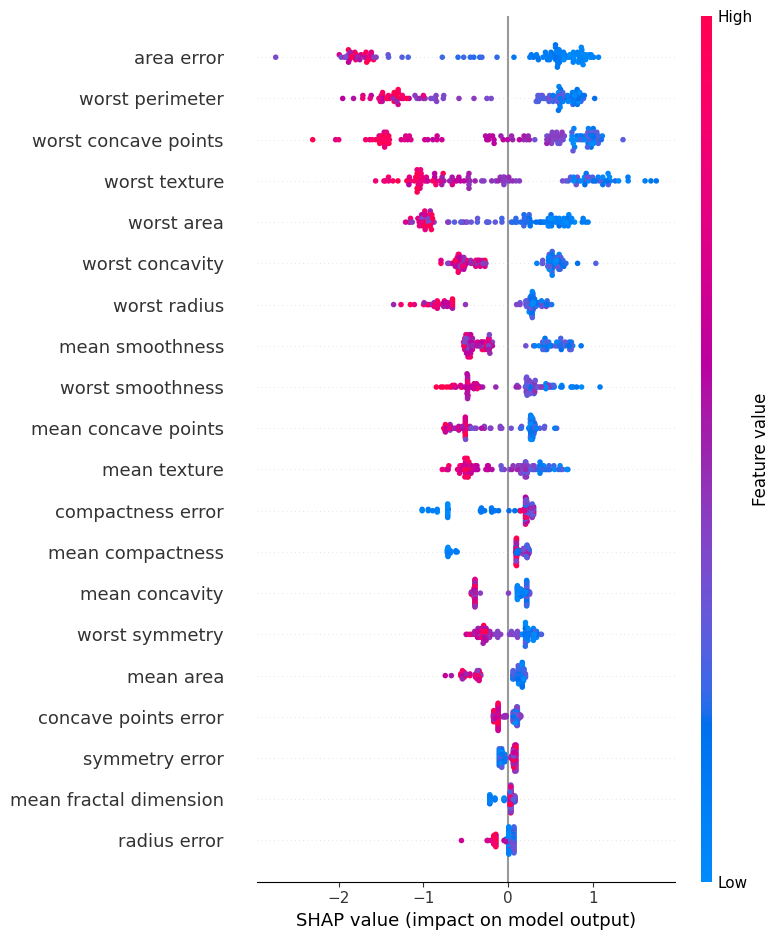

In [25]:
import shap

explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_test)
explainer = shap.Explainer(best_xgb, X_train)

shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

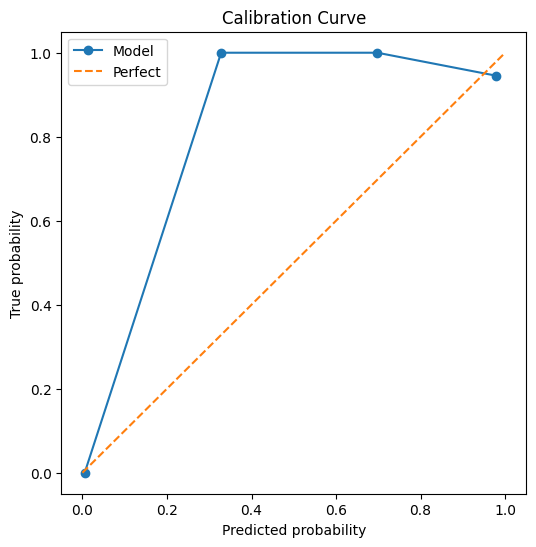

In [32]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

probs = best_xgb.predict_proba(X_test)[:, 1]
prob_true, prob_pred = calibration_curve(
    y_test,
    probs,
    n_bins=5
)

plt.figure(figsize=(6,6))

plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0,1],[0,1],"--", label="Perfect")

plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.title("Calibration Curve")

plt.legend()
plt.show()

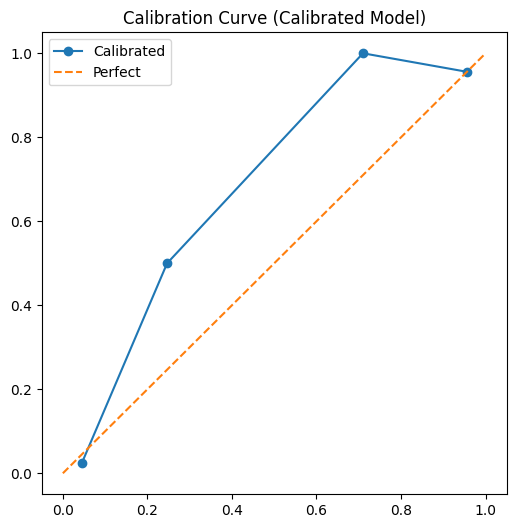

In [33]:
from sklearn.calibration import CalibratedClassifierCV

cal_model = CalibratedClassifierCV(
    rf,   # or best_xgb
    method="sigmoid",
    cv=5
)

cal_model.fit(X_train, y_train)

probs_cal = cal_model.predict_proba(X_test)[:, 1]
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test,
    probs_cal,
    n_bins=5
)
plt.figure(figsize=(6,6))

plt.plot(prob_pred, prob_true, marker="o", label="Calibrated")
plt.plot([0,1],[0,1],"--", label="Perfect")

plt.legend()
plt.title("Calibration Curve (Calibrated Model)")
plt.show()

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [46]:
probs = rf.predict_proba(X_test)

confidence = probs.max(axis=1)

preds = rf.predict(X_test)

for i in range(5):
    print(
        "Pred:", preds[i],
        "Confidence:", confidence[i]
    )

Pred: 0 Confidence: 1.0
Pred: 1 Confidence: 1.0
Pred: 0 Confidence: 0.88
Pred: 0 Confidence: 0.72
Pred: 0 Confidence: 0.99


In [49]:
df_dice = df.copy()

feature_names = X.columns.tolist()

target_name = "target"

In [50]:
import dice_ml
from dice_ml import Dice
data_dice = dice_ml.Data(
    dataframe=df_dice,
    continuous_features=feature_names,
    outcome_name=target_name
)
rf.fit(X_train, y_train)
model_dice = dice_ml.Model(
    model=rf,
    backend="sklearn"
)
exp = Dice(
    data_dice,
    model_dice,
    method="random"
)
query = X_test.iloc[0:1]

cf = exp.generate_counterfactuals(
    query,
    total_CFs=2,
    desired_class="opposite"
)

cf.visualize_as_dataframe()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.21it/s]

Query instance (original outcome : 0)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,19.549999,28.77,133.600006,1207.0,0.0926,0.2063,0.1784,0.1144,0.1893,0.06232,...,36.27,178.600006,1926.0,0.1281,0.5329,0.4251,0.1941,0.2818,0.1005,0



Diverse Counterfactual set (new outcome: 1)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,19.55,28.77,133.6,645.8,0.0695,0.2608,0.1784,0.0000,0.1893,0.06232,...,36.27,88.7,1926.0,0.0975,0.5329,0.0,0.1,0.2306,0.1005,1
1,19.55,28.77,133.6,645.8,0.0695,0.2608,0.1784,0.1144,0.1893,0.06232,...,36.27,88.7,1926.0,0.0975,0.5329,0.0,0.1,0.2306,0.1005,0
